# Activity: Static Word Embedding & Large Word Embedding  

**Author:** Louis G. Binwag  
**References:** Course notebooks (`.ipynb`)  


# **Word Embeddings**

The requirements for this stage of the analysis are:

1. Most similar words (Using Static Word Embedding) from the top occurring words (max of 3 words, from Term-Frequency Language Model).
2. PCA of the words from the top 3 words (from the Term-Frequency Language Model).
3. Application of a Hugging Face model to your dataset (BERT-based topic model, BERT-based Sentiment / Emotion model)

As such, I am going to apply similarly the processes used in the lecture and course notes on the preprocessed dataset, considering mostly the `cleaned text` attribute of reddit_cleaned.csv

In [4]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
import joblib
import pandas as pd

from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [5]:
corpus = pd.read_csv("../Binwag - PhilippineRedditAgricultureAnalysis/data/reddit_title_topics.csv")
corpus.head()

,post_title,comment,created_utc,cleaned_comment,cleaned_post_title,cleaned_text,Dominant_Topic
0,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",NaN,2025-07-07 11:40:47,NaN,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
1,"Sen. Marcoleta to hold Blue Ribbon Committee, ...","Buti naman si Kiko papalit sa Agriculture, dam...",2025-07-07 12:38:47,buti naman si kiko papalit sa agriculture dam ...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
2,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",May sumpa rin ang blue ribbon. \n\nTolentino -...,2025-07-07 12:21:50,may sumpa rin ang blue ribbon tolentino talogo...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
3,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",Bobo naman bakit sa kanya Blue Ribbon Committee,2025-07-07 11:51:43,bobo naman bakit sa kanya blue ribbon committee,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
4,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",Blue Ribbon Committee is a curse seat lol yeah...,2025-07-07 12:46:06,blue ribbon committee curse seat lol yeah maga...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2


## **Bag of Words Model**

In [6]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

added_stopwords = [
    "sa", "na", "ng", "ang", "mga", "yung", "pa", "lang", "naman", "ba",
    "ko", "mo", "nila", "pero", "daw", "din", "rin", "kasi", "nga", "eh",
    "si", "ni", "kay", "para", "kung", "ay", "lahat", "wala", "may", "meron",
    "dapat", "talaga", "ano", "oo", "hindi", "diba", "sobrang", "super",
    "mas", "isa", "dalawa", "tatlo", "sen", "say", "ma", "make", "ako", "ka"
]

custom_stopwords = list(set(ENGLISH_STOP_WORDS).union(added_stopwords))

In [7]:
bow_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    # stop_words=custom_stopwords
)

doc2vec_bow = bow_vectorizer.fit_transform(corpus['cleaned_text'])
doc2vec_bow = pd.DataFrame(doc2vec_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())
doc2vec_bow.head()

# Save to file
doc2vec_bow.to_pickle('doc2vec_bow.pkl')

# Load from file
doc2vec_bow = pd.read_pickle('doc2vec_bow.pkl')

In [8]:
def top_n_grams(document, top_n=10):
  return document.sort_values(ascending=False).index[:top_n].tolist()

In [9]:
doc2vec_bow.apply(lambda document:
                  top_n_grams(document, top_n=5),
                  axis=1)

0        [sen, sen bam, blue ribbon, ribbon committee, ...
1                       [sen, agriculture, kiko, bam, dam]
2        [sen, ribbon, blue ribbon, blue, taloguingona ...
3         [sen, committee, blue, ribbon, ribbon committee]
4        [sen, blue ribbon, ribbon, ribbon committee, b...
                               ...                        
13166    [tie, deepen tie, infrastructure plan, japan d...
13167    [philippine japan, thats scary, deepen, deepen...
13168    [tie 15, partnership daijoubu, deepen, japan d...
13169    [deepen tie, theyre less, although, connection...
13170                        [ng, russia, sa, mga, ng mga]
Length: 13171, dtype: object

In [10]:
# Wordcloud using BoW and TF-IDF
def plot_wordcloud(data, title):
  wordcloud = WordCloud(
    width=800, height=400, background_color='white'
  ).generate_from_frequencies(data)
  plt.figure(figsize=(10, 6))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.title(title)
  plt.show()

sa              8430
na              8233
ng              6352
ang             5378
philippine      4132
agriculture     3976
mga             3720
yung            2777
pa              2549
lang            2387
may             2254
rice            1807
farmer          1710
ko              1673
go              1617
mo              1542
agricultural    1423
naman           1403
ba              1360
get             1277
dtype: int64


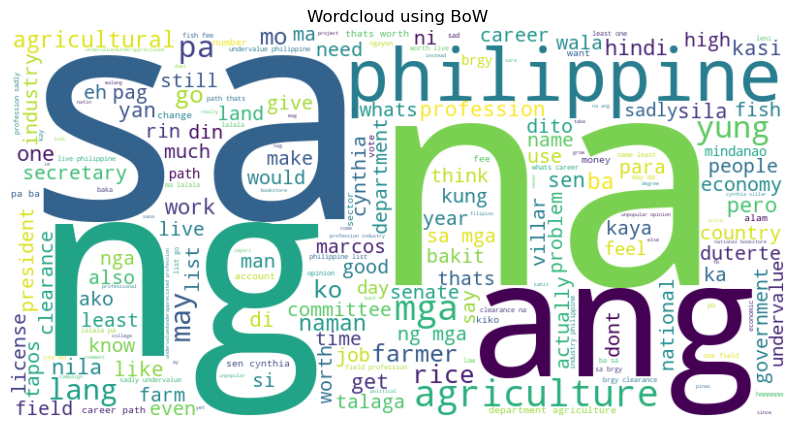

In [11]:
bow_frequencies = doc2vec_bow.sum(axis=0).sort_values(ascending=False)
print(bow_frequencies.head(20))
plot_wordcloud(bow_frequencies, 'Wordcloud using BoW')

## **Analysis based on this BoW (Including knowledge from Data Preprocessing and EDA Steps)**

I still need to find the working way to implement stop-words. It seems that the dataset is still ignoring the stop-words i had implemented.

But for the sake of analysis, we can ignore the stopwords and the top words based on frequency would be:
1. Philippine
2. Agriculture
3. Rice
4. Farmer
5. Agricultural

Which could mean based on what I understand is that there are frequent conversations pertaining to Rice Farming. And based as well on my knowledge on the field, Rice-Farming is the most controversial part of agriculture, followed by Fisheries and then vegetations.

This could mean a number of possible things:

- Polarized discussions on Rice Farming
- Frequent concerns of farmers stemming from keywords found on the set
    - Undervalued (possibly as a profession or as a means)
    - Government or Political platform issues regarding farmers/farming/rice/agriculture
    - Land concerns, previously mentioned in EDA "Cynthia Villar" is reknowned for abusing farmers.

# **Implementing Static Word Embeddings**

In [12]:
%pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [13]:
import gensim

In [14]:
corpus.head()

,post_title,comment,created_utc,cleaned_comment,cleaned_post_title,cleaned_text,Dominant_Topic
0,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",NaN,2025-07-07 11:40:47,NaN,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
1,"Sen. Marcoleta to hold Blue Ribbon Committee, ...","Buti naman si Kiko papalit sa Agriculture, dam...",2025-07-07 12:38:47,buti naman si kiko papalit sa agriculture dam ...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
2,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",May sumpa rin ang blue ribbon. \n\nTolentino -...,2025-07-07 12:21:50,may sumpa rin ang blue ribbon tolentino talogo...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
3,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",Bobo naman bakit sa kanya Blue Ribbon Committee,2025-07-07 11:51:43,bobo naman bakit sa kanya blue ribbon committee,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2
4,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",Blue Ribbon Committee is a curse seat lol yeah...,2025-07-07 12:46:06,blue ribbon committee curse seat lol yeah maga...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2


In [15]:
# Tokenize the text
corpus['tokenized_text'] = corpus['cleaned_text'].apply(lambda x: x.split())

In [16]:
display(
  corpus['cleaned_text'].head()
)

display(
  corpus['tokenized_text'].head()
)

0    sen marcoleta hold blue ribbon committee sen b...
1    sen marcoleta hold blue ribbon committee sen b...
2    sen marcoleta hold blue ribbon committee sen b...
3    sen marcoleta hold blue ribbon committee sen b...
4    sen marcoleta hold blue ribbon committee sen b...
Name: cleaned_text, dtype: object

0    [sen, marcoleta, hold, blue, ribbon, committee...
1    [sen, marcoleta, hold, blue, ribbon, committee...
2    [sen, marcoleta, hold, blue, ribbon, committee...
3    [sen, marcoleta, hold, blue, ribbon, committee...
4    [sen, marcoleta, hold, blue, ribbon, committee...
Name: tokenized_text, dtype: object

In [17]:
model = gensim.models.Word2Vec(corpus['tokenized_text'],
                               vector_size=100,  # Dimension of the word vectors
                               min_count=1,    # Ignores all words with total frequency lower min_count
                               sg=0,           # Training algorithm: 0 for CBOW; 1 for Skip-gram
                               window=5,       # Maximum distance between the current & predicted word within a sentence
                               workers=4,      # Number of workers to use for training
                               epochs=10       # Number of iterations over the corpus
                               )

model.save('word2vec.model')

In [18]:
# Load the model
model = gensim.models.Word2Vec.load('word2vec.model')

# Get vectors from the model
vectors = model.wv

In [19]:
# Number of word vectors generated (columns)
len(vectors)

28803

In [20]:
# List of words / tokens sorted by most frequent
vectors.index_to_key
vectors.index_to_key[:20]  

['sa',
 'na',
 'ng',
 'ang',
 'philippine',
 'agriculture',
 'mga',
 'yung',
 'pa',
 'lang',
 'may',
 'rice',
 'farmer',
 'ko',
 'go',
 'mo',
 'agricultural',
 'naman',
 'ba',
 'get']

In [21]:
# The similarity method returns a score of how similar the vectors of two words are. 
# The closer the score is to 1, the higher the similarity. The closer to 0, the lower the similarity.
vectors.similarity('agriculture', 'philippine')

0.30883256

In [22]:

vectors.similarity('rice', 'philippine')

0.28054777

In [23]:

vectors.similarity('farmer', 'philippine')

0.33439812

In [24]:

vectors.similarity('rice', 'agriculture')

0.31383657

In [25]:
# The most_similar method returns words whose vectors are most similar to the given word.
vectors.most_similar('farmer', topn=15)

[('owner', 0.72581946849823),
 ('small', 0.7148101329803467),
 ('upgrade', 0.7014292478561401),
 ('instead', 0.6918115019798279),
 ('distribute', 0.6849085688591003),
 ('plotsbetter', 0.6790363192558289),
 ('sectorsthis', 0.6748459339141846),
 ('local', 0.6665474772453308),
 ('newlymade', 0.6654770374298096),
 ('interest', 0.6650249361991882),
 ('research', 0.6647432446479797),
 ('headquarter', 0.6642583012580872),
 ('middleman', 0.6610598564147949),
 ('goal', 0.6575614809989929),
 ('thereby', 0.6563748121261597)]

In [26]:
# The most_similar method returns words whose vectors are most similar to the given word.
vectors.most_similar('villar', topn=15)

[('cynthia', 0.9300254583358765),
 ('hutaena', 0.8781569600105286),
 ('madame', 0.8666201233863831),
 ('aling', 0.8510251641273499),
 ('bigkas', 0.841593861579895),
 ('sen', 0.8244217038154602),
 ('nakakapanglata', 0.8177002668380737),
 ('villiar', 0.8099368214607239),
 ('villarmas', 0.8003057241439819),
 ('hoa', 0.7903463840484619),
 ('distractedthe', 0.7901784777641296),
 ('chairperson', 0.7848243713378906),
 ('skay', 0.7844060659408569),
 ('plang', 0.7810149192810059),
 ('researchresearch', 0.7790058851242065)]

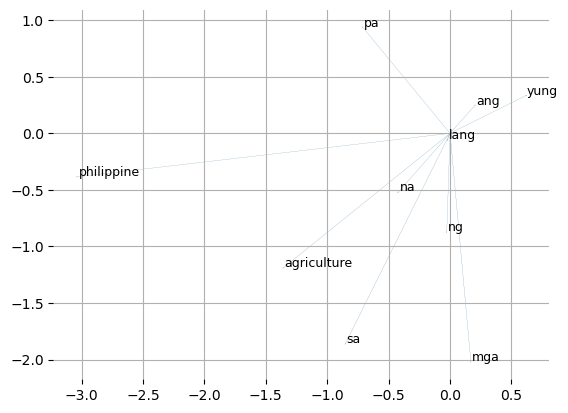

In [27]:
# Plot word vectors
def plot_vectors(vectors, words):
  # Create a figure and a 2D Axes
  fig, ax = plt.subplots()

  for word in words:
    # Get the vector for the word
    vector = vectors[word]

    # Plot the word near the arrow head
    ax.text(vector[0] + 0.01, vector[1] + 0.01, word, fontsize=9)
    # Plot the vector
    ax.arrow(
      0,                      # Start x
      0,                      # Start y
      vector[0],              # End x
      vector[1],              # End y
      # head_width=0.05,      # Arrow head width
      # head_length=0.1       # Arrow head length
      head_width=0.05 * 0.1,  # Arrow head width
      head_length=0.1 * 0.1,  # Arrow head length
      lw=0.01,                # Arrow line width
      # fc='r',                 # Arrow fill color
      # ec='r'                  # Arrow edge color
    )

  # Remove border around the plot
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  ax.spines['bottom'].set_visible(False)
  ax.spines['left'].set_visible(False)

  plt.grid()

  # Display the plot
  plt.show()


plot_vectors(vectors, vectors.index_to_key[:10])

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [29]:
# Words most similar to "rice"
vectors.most_similar('rice', topn=5)
word_set1 = [word for word, score in vectors.most_similar('pogo', topn=5)]
word_set1

['earth', '2024as', 'hardbound', 'ibatibang', 'reclaim']

In [30]:
# Words most similar to 'agriculture'
vectors.most_similar('agriculture', topn=5)
word_set2 = [word for word, score in vectors.most_similar('scam', topn=5)]
word_set2

['component', 'resume', 'frequent', 'mission', 'accredit']

In [31]:
words_to_viz = word_set1 + word_set2
words_to_viz

['earth',
 '2024as',
 'hardbound',
 'ibatibang',
 'reclaim',
 'component',
 'resume',
 'frequent',
 'mission',
 'accredit']

In [32]:
vecs_to_viz = [vectors[word] for word in words_to_viz]
vecs_to_viz

[array([-0.22695336, -0.385554  , -0.32354546, -0.10867938,  0.31581473,
         0.00486386,  0.03762456,  0.284597  ,  0.03422634, -0.26271218,
        -0.04088752, -0.01953127, -0.12012573,  0.23674685, -0.11527021,
        -0.08150879, -0.15104842,  0.12946796,  0.15854998, -0.48559624,
        -0.2011683 ,  0.00945744, -0.11307756, -0.06583414,  0.20419465,
        -0.14049701, -0.045349  , -0.01569461,  0.21113002,  0.04268919,
        -0.010337  ,  0.3062173 , -0.10303343, -0.1503365 ,  0.0343483 ,
        -0.1962869 , -0.22135094, -0.4099193 ,  0.15221451, -0.07981698,
         0.12347257, -0.17513719, -0.1027104 , -0.08379796,  0.16968936,
        -0.17710896, -0.08767354, -0.02487829, -0.29760852, -0.04670678,
         0.16719781,  0.02705934, -0.12102826,  0.15666077,  0.2712795 ,
         0.28733826,  0.19547738,  0.17364024,  0.2494879 , -0.11273046,
        -0.03537289, -0.1155201 ,  0.05354064,  0.13207348, -0.47837803,
         0.01906506, -0.17764154,  0.08260657, -0.2

In [33]:
pca = PCA(n_components=2)
vecs_PCA = pca.fit_transform(vecs_to_viz)
vecs_PCA

array([[-0.98234742,  0.35542974],
       [ 0.58885912,  0.11384478],
       [ 0.36422704,  0.13340161],
       [ 0.21671556,  0.15355322],
       [ 0.26926304,  0.06528448],
       [ 0.02395139, -0.18950489],
       [-0.1238851 , -0.15847295],
       [ 0.00201401, -0.17367544],
       [ 0.25502636, -0.01856816],
       [-0.61382401, -0.2812924 ]])

In [34]:
vecs_PCA_df = pd.DataFrame(columns=['word', 'association', 'PC1', 'PC2'])

for idx in range(len(words_to_viz)):
  word = words_to_viz[idx]
  association = 'agriculture' if word in word_set1 else 'rice'
  PC1 = vecs_PCA[idx, 0]
  PC2 = vecs_PCA[idx, 1]
  new_row = [word, association, PC1, PC2]

  vecs_PCA_df.loc[len(vecs_PCA_df)] = new_row

vecs_PCA_df

,word,association,PC1,PC2
0,earth,agriculture,-0.982347,0.355430
1,2024as,agriculture,0.588859,0.113845
2,hardbound,agriculture,0.364227,0.133402
3,ibatibang,agriculture,0.216716,0.153553
4,reclaim,agriculture,0.269263,0.065284
5,component,rice,0.023951,-0.189505
6,resume,rice,-0.123885,-0.158473
7,frequent,rice,0.002014,-0.173675
8,mission,rice,0.255026,-0.018568
9,accredit,rice,-0.613824,-0.281292


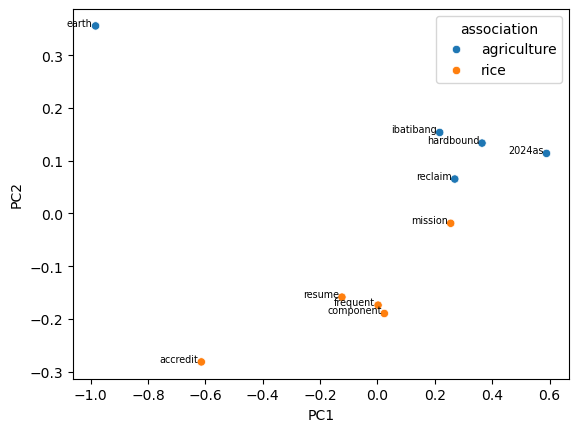

In [35]:
vecs_viz = sns.scatterplot(data=vecs_PCA_df, x='PC1', y='PC2', hue='association')
for idx in range(len(words_to_viz)):
  vecs_viz.text(vecs_PCA_df.PC1[idx] - 0.01, vecs_PCA_df.PC2[idx], vecs_PCA_df.word[idx], horizontalalignment='right',
                size='x-small', color='black', weight='light')
vecs_viz

plt.show()

In [36]:
def viz_associated_wordvecs(word1, word2, topn=5, model=vectors):
  word_set1 = [model.most_similar(word1, topn=topn)[idx][0] for idx in range(topn)]
  word_set2 = [model.most_similar(word2, topn=topn)[idx][0] for idx in range(topn)]
  words_to_viz = word_set1 + word_set2
  vecs_to_viz = [model[word] for word in words_to_viz]

  pca = PCA(n_components=2)
  vecs_PCA = pca.fit_transform(vecs_to_viz)
  vecs_PCA_df = pd.DataFrame(columns=['word', 'association', 'PC1', 'PC2'])

  for idx in range(len(words_to_viz)):
    word = words_to_viz[idx]
    association = word1 if word in word_set1 else word2
    PC1 = vecs_PCA[idx, 0]
    PC2 = vecs_PCA[idx, 1]
    new_row = [word, association, PC1, PC2]
    vecs_PCA_df.loc[len(vecs_PCA_df)] = new_row

  vecs_viz = sns.scatterplot(data=vecs_PCA_df, x='PC1', y='PC2', hue='association')

  for idx in range(len(words_to_viz)):
    vecs_viz.text(vecs_PCA_df.PC1[idx] - 0.01, vecs_PCA_df.PC2[idx], vecs_PCA_df.word[idx], horizontalalignment='right',
                  size='x-small', color='black', weight='light')
  return vecs_PCA_df

,word,association,PC1,PC2
0,subsequently,rice,1.653192,0.439804
1,2023,rice,-1.150049,-2.670133
2,food,rice,-8.066993,0.905715
3,x100,rice,1.791084,0.406587
4,17,rice,1.126267,0.169094
5,stepchild,farm,1.805663,0.450144
6,courserequirement,farm,1.741683,0.418177
7,mixeduse,farm,1.765151,0.467160
8,mechanization,farm,0.014962,-0.251916
9,technology,farm,-0.680961,-0.334632


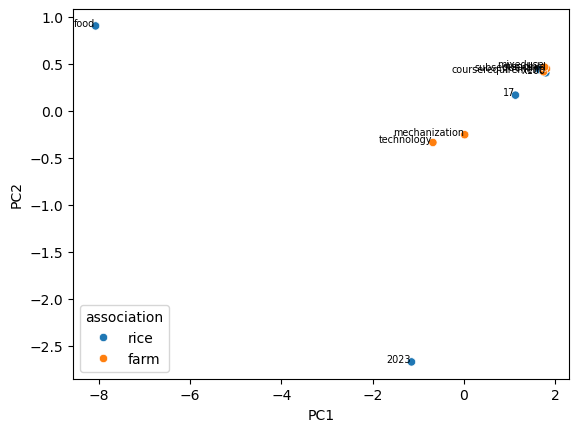

In [37]:
viz_associated_wordvecs('rice', 'farm', topn=5, model=vectors)

,word,association,PC1,PC2
0,andamo,philippine,-0.575851,-0.017159
1,astro,philippine,-0.437375,-0.010631
2,doubtful,philippine,-0.613722,-0.087426
3,versatility,philippine,-0.477400,-0.068593
4,ulture,philippine,-0.497943,-0.061870
5,stepchild,farm,-0.532823,-0.012725
6,courserequirement,farm,-0.461240,0.019005
7,mixeduse,farm,-0.519500,0.014527
8,mechanization,farm,1.562482,0.702784
9,technology,farm,2.553372,-0.477915


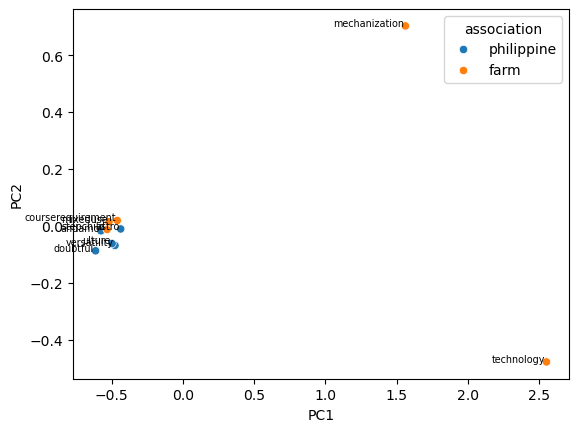

In [38]:
viz_associated_wordvecs('philippine', 'farm', topn=5, model=vectors)

,word,association,PC1,PC2
0,cynthia,villar,-12.345520,-0.038272
1,hutaena,villar,1.463768,-0.613050
2,madame,villar,1.395914,-0.697094
3,aling,villar,0.975223,-0.580341
4,bigkas,villar,1.209216,-0.716304
5,stepchild,farm,1.612371,-0.511348
6,courserequirement,farm,1.600483,-0.441836
7,mixeduse,farm,1.627221,-0.497298
8,mechanization,farm,1.107009,1.519250
9,technology,farm,1.354314,2.576294


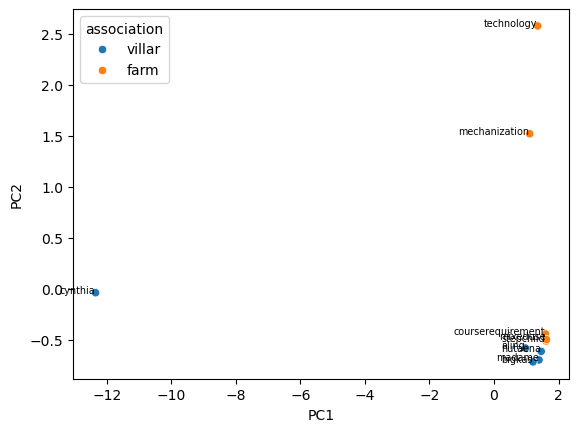

In [39]:
viz_associated_wordvecs('villar', 'farm', topn=5, model=vectors)

,word,association,PC1,PC2
0,undervalue,profession,-7.169047,0.225695
1,sadly,profession,-6.480787,-0.886089
2,undervaluedunderappreciated,profession,-5.797055,0.936109
3,psychologist,profession,3.414144,4.790134
4,field,profession,-3.597783,1.043729
5,owner,farmer,4.593944,2.800806
6,small,farmer,3.784837,-4.546006
7,upgrade,farmer,4.613369,4.860966
8,instead,farmer,3.601480,-2.420932
9,distribute,farmer,3.036898,-6.804411


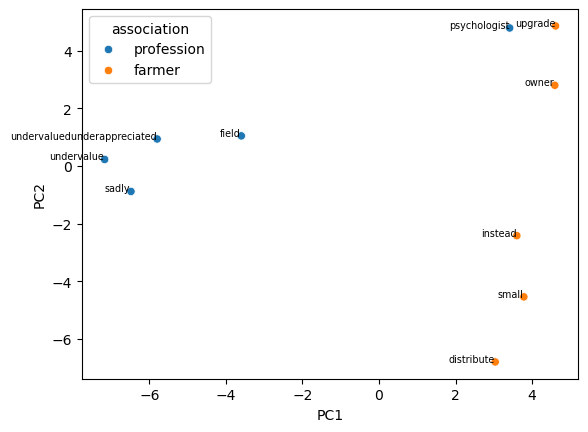

In [40]:
viz_associated_wordvecs('profession', 'farmer', topn=5, model=vectors)

## **Short Analysis for Static Word Embeddings and PCA**

Looking at these graphical representation (PCA) of Static Word Embeddings, it looks like Agriculture and Philippines does not seem to be aligned.

Despite being geographically advantageous as a agricultural country, based on these embeddings it seems that a lot of sentiments regarding agriculture is the fact that agriculture is undervalued. Historically, this probably stems from the lack of governmental support for our agriculture, or, could be an on-going trend especially that 'tech' or 'med' is becoming the hit profession, which causes stereotyping when it comes to agriculture or farming, making it undervalued.

However, this could also stem from the fact that the dataset may be heavily populated with tagalog words, and the methods applied may be inefficient (could probably require fine-tuning for tagalog-lexicon?)

# **Large Word Embeddings**

In [41]:
%pip install transformers triton

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement triton (from versions: none)
ERROR: No matching distribution found for triton


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformers import pipeline
from tqdm import tqdm
tqdm.pandas()

In [43]:
corpus[["created_utc","post_title","cleaned_text"]].head()

,created_utc,post_title,cleaned_text
0,2025-07-07 11:40:47,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",sen marcoleta hold blue ribbon committee sen b...
1,2025-07-07 12:38:47,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",sen marcoleta hold blue ribbon committee sen b...
2,2025-07-07 12:21:50,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",sen marcoleta hold blue ribbon committee sen b...
3,2025-07-07 11:51:43,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",sen marcoleta hold blue ribbon committee sen b...
4,2025-07-07 12:46:06,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",sen marcoleta hold blue ribbon committee sen b...


In [44]:
# from transformers import pipeline

# # https://huggingface.co/tabularisai/multilingual-sentiment-analysis

# # @misc{tabularisai_2025,
# #     author       = { tabularisai and Samuel Gyamfi and Vadim Borisov and Richard H. Schreiber },
# #     title        = { multilingual-sentiment-analysis (Revision 69afb83) },
# #     year         = 2025,
# #     url          = { https://huggingface.co/tabularisai/multilingual-sentiment-analysis },
# #     doi          = { 10.57967/hf/5968 },
# #     publisher    = { Hugging Face }
# # }

# # Load the classification pipeline with the specified model
# pipe = pipeline("text-classification", model="tabularisai/multilingual-sentiment-analysis")

# # Classify a new sentence
# sentence = "I love this product! It's amazing and works perfectly."
# result = pipe(sentence)

# # Print the result
# print(result)

sentiment_analyzer = pipeline('sentiment-analysis',
                              model='nlptown/bert-base-multilingual-uncased-sentiment',
                              device=0)

In [45]:
result = sentiment_analyzer(
  "Hugging Face's BERT models are great."
)
print(result)

[{'label': '5 stars', 'score': 0.6625104546546936}]


In [46]:
short_title = corpus[corpus['post_title'].str.len() < 512].copy()
short_title.tail()

,post_title,comment,created_utc,cleaned_comment,cleaned_post_title,cleaned_text,Dominant_Topic,tokenized_text
13166,"Philippines, Japan deepen ties with $1.5 billi...",That’s why fuck the Dutertes,2024-05-03 11:30:11,thats fuck dutertes,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1,"[philippine, japan, deepen, tie, 15, billion, ..."
13167,"Philippines, Japan deepen ties with $1.5 billi...",Fr? That's scary.,2024-05-03 12:32:41,fr thats scary,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1,"[philippine, japan, deepen, tie, 15, billion, ..."
13168,"Philippines, Japan deepen ties with $1.5 billi...",This partnership is very daijoubu,2024-05-03 10:33:52,partnership daijoubu,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1,"[philippine, japan, deepen, tie, 15, billion, ..."
13169,"Philippines, Japan deepen ties with $1.5 billi...","Yeah, there’s a huge connection between corrup...",2024-05-03 12:36:12,yeah there huge connection corrupt countriesth...,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1,"[philippine, japan, deepen, tie, 15, billion, ..."
13170,"Philippines, Japan deepen ties with $1.5 billi...","Yup ganyan din ginagawa ng Russia, kaya mas pi...",2024-05-03 16:57:35,yup ganyan din ginagawa ng russia kaya ma pini...,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1,"[philippine, japan, deepen, tie, 15, billion, ..."


In [47]:
sentiment_analyzer(short_title["post_title"].iloc[0])


[{'label': '4 stars', 'score': 0.35326671600341797}]

In [48]:
short_title[['sentiment', 'sentiment_confidence']] = short_title.progress_apply(
  lambda row: pd.Series(sentiment_analyzer(row['post_title'])[0]),
  axis=1
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13171/13171 [02:04<00:00, 105.40it/s]


In [49]:
short_title.tail()

,post_title,comment,created_utc,cleaned_comment,cleaned_post_title,cleaned_text,Dominant_Topic,tokenized_text,sentiment,sentiment_confidence
13166,"Philippines, Japan deepen ties with $1.5 billi...",That’s why fuck the Dutertes,2024-05-03 11:30:11,thats fuck dutertes,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1,"[philippine, japan, deepen, tie, 15, billion, ...",5 stars,0.385458
13167,"Philippines, Japan deepen ties with $1.5 billi...",Fr? That's scary.,2024-05-03 12:32:41,fr thats scary,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1,"[philippine, japan, deepen, tie, 15, billion, ...",5 stars,0.385458
13168,"Philippines, Japan deepen ties with $1.5 billi...",This partnership is very daijoubu,2024-05-03 10:33:52,partnership daijoubu,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1,"[philippine, japan, deepen, tie, 15, billion, ...",5 stars,0.385458
13169,"Philippines, Japan deepen ties with $1.5 billi...","Yeah, there’s a huge connection between corrup...",2024-05-03 12:36:12,yeah there huge connection corrupt countriesth...,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1,"[philippine, japan, deepen, tie, 15, billion, ...",5 stars,0.385458
13170,"Philippines, Japan deepen ties with $1.5 billi...","Yup ganyan din ginagawa ng Russia, kaya mas pi...",2024-05-03 16:57:35,yup ganyan din ginagawa ng russia kaya ma pini...,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1,"[philippine, japan, deepen, tie, 15, billion, ...",5 stars,0.385458


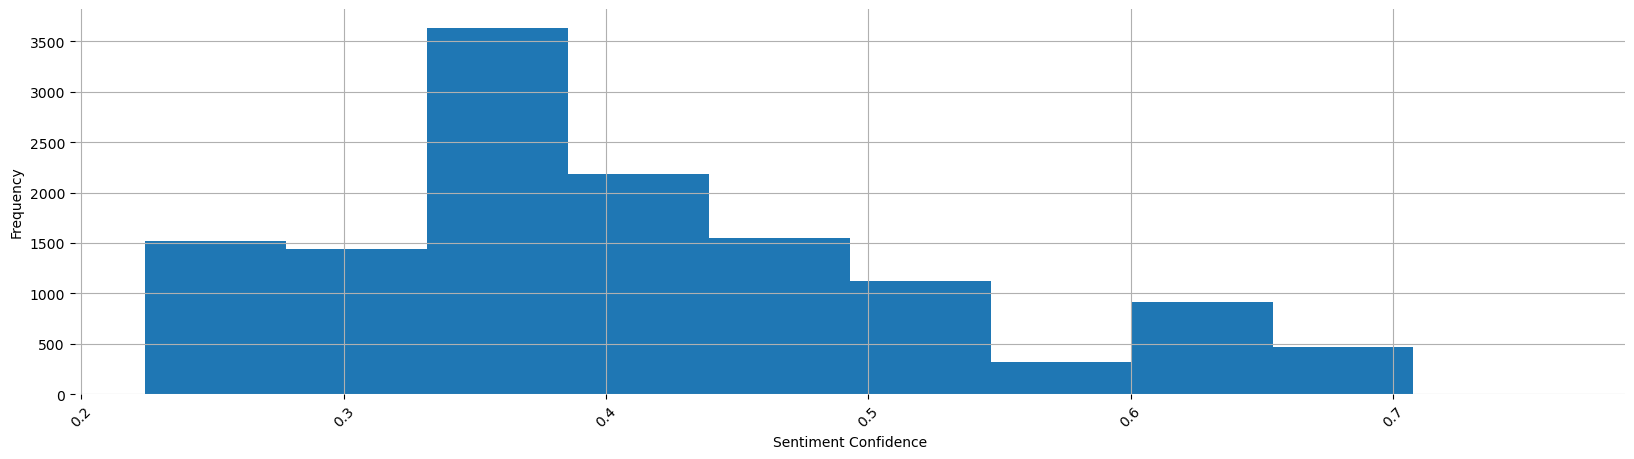

sentiment
1 star     6877
5 stars    2496
3 stars    2070
2 stars     934
4 stars     794
Name: count, dtype: int64

In [50]:
fig, ax = plt.subplots(figsize=(20, 5))
short_title['sentiment_confidence'].hist(ax=ax)

# Set labels
ax.set_xlabel('Sentiment Confidence')
ax.set_ylabel('Frequency')

# 45 degree angle for x-axis labels
ax.tick_params(axis='x', rotation=45)

# No spines
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

short_title['sentiment'].value_counts()

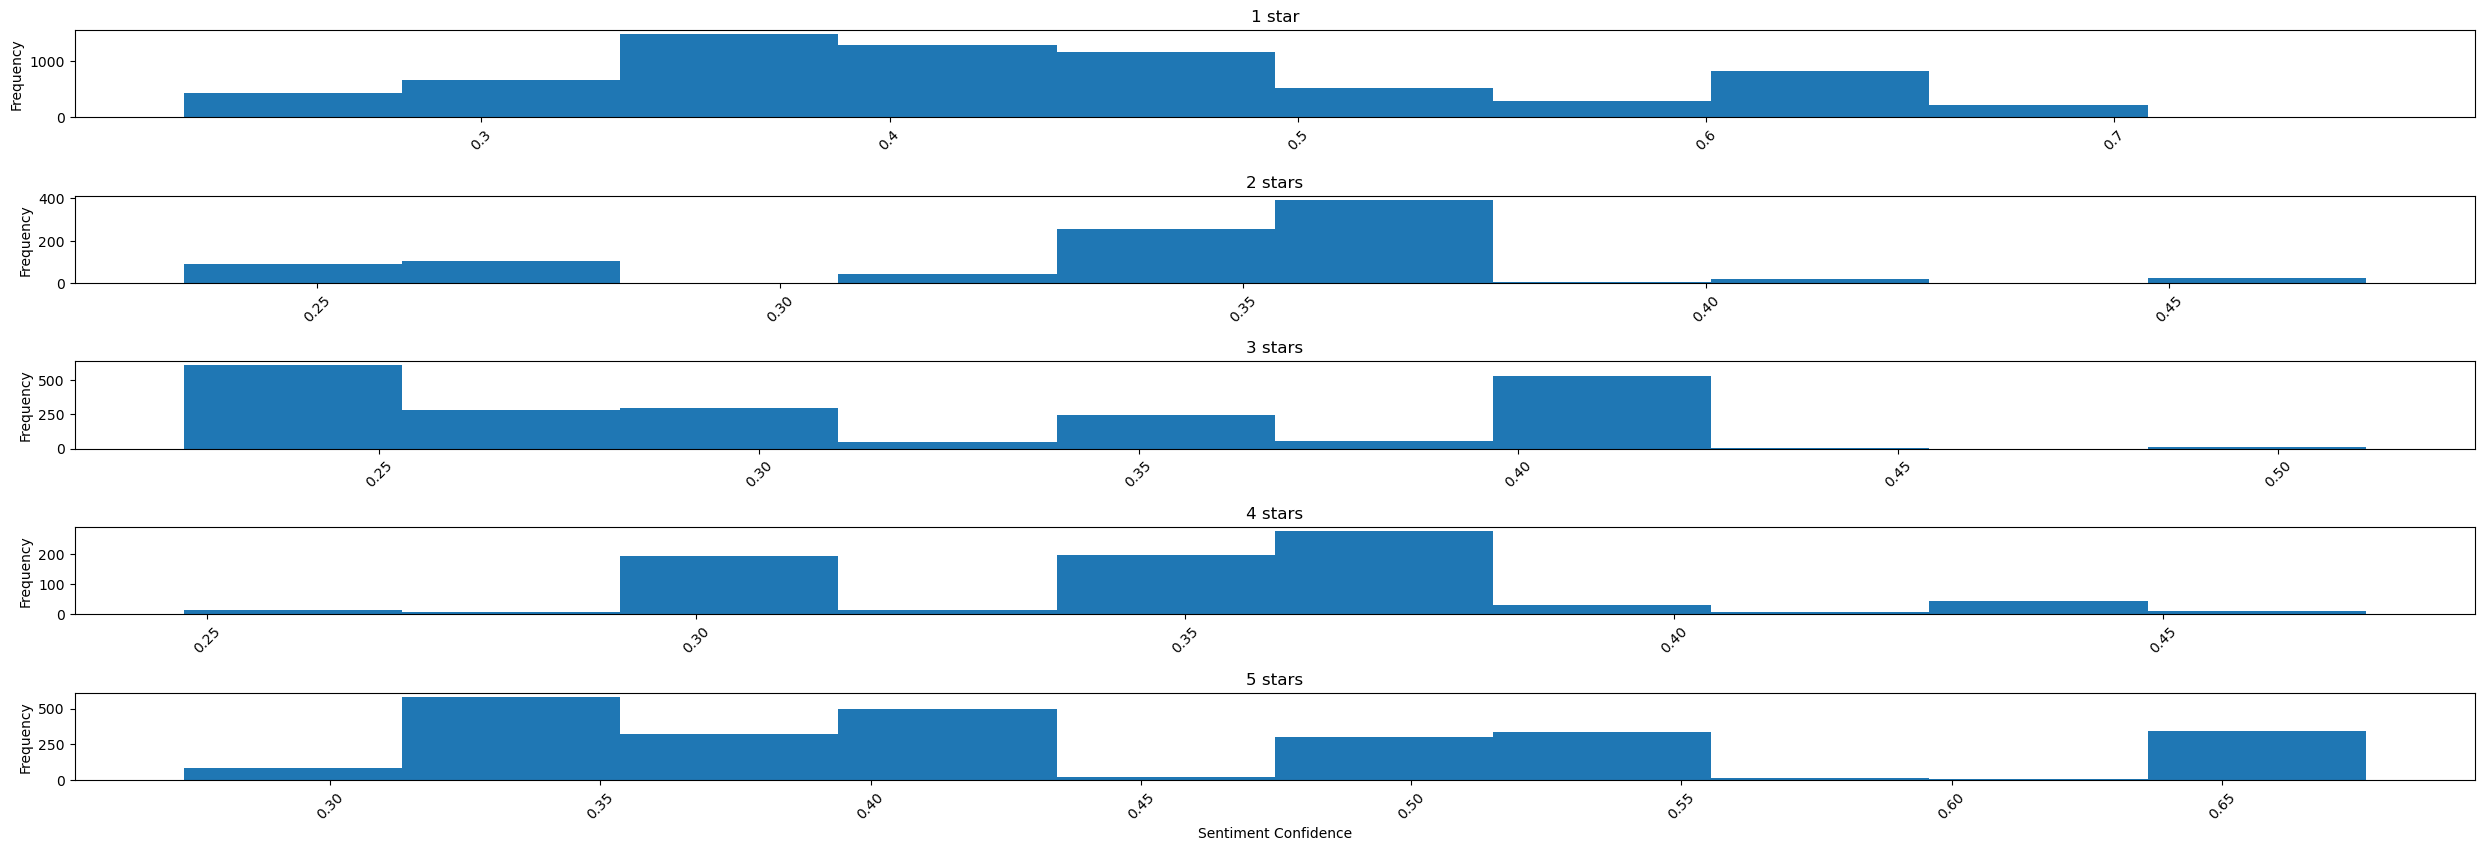

In [51]:
# Histogram of sentiment confidence along with the sentiment
fig, ax = plt.subplots(5, figsize=(30, 10))

short_title['sentiment_confidence'].hist(
  by=short_title['sentiment'],
  ax=ax,
)

# Add more space between subplots
plt.subplots_adjust(hspace=0.9)

# Set labels
ax[4].set_xlabel('Sentiment Confidence')
for a in ax:
  a.set_ylabel('Frequency')
  # 45 degree angle for x-axis labels
  a.tick_params(axis='x', rotation=45)

plt.show()

In [52]:
%pip install bertopic==0.16.0 transformers==4.44.2


Note: you may need to restart the kernel to use updated packages.


In [53]:
import bertopic, transformers
print("BERTopic:", bertopic.__version__)
print("Transformers:", transformers.__version__)


BERTopic: 0.16.0
Transformers: 4.44.2


In [54]:
from bertopic import BERTopic

In [55]:
# fill NaN values with empty strings
corpus['cleaned_text'] = corpus['cleaned_text'].fillna('blank')

In [56]:
topic_model = BERTopic(language="multilingual",
                       calculate_probabilities=True, verbose=True,
                       n_gram_range=(1, 1), min_topic_size=3
                       )
topics, probs = topic_model.fit_transform(corpus['cleaned_text'])

2025-09-19 23:46:22,617 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/412 [00:00<?, ?it/s]

2025-09-19 23:48:10,017 - BERTopic - Embedding - Completed ✓
2025-09-19 23:48:10,018 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-09-19 23:48:29,334 - BERTopic - Dimensionality - Completed ✓
2025-09-19 23:48:29,336 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-09-19 23:51:21,713 - BERTopic - Cluster - Completed ✓
2025-09-19 23:51:21,721 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-09-19 23:51:22,382 - BERTopic - Representation - Completed ✓


In [57]:
len(corpus)

13171

In [58]:
topic_dataframe = topic_model.get_topic_info()
topic_dataframe

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1754,-1_clearance_industry_brgy_lalala,"[clearance, industry, brgy, lalala, undervalue...",[tigilan niyo na yang mga researchresearch sen...
1,0,477,0_path_worth_career_whats,"[path, worth, career, whats, live, thats, sala...",[whats career path thats worth live philippine...
2,1,476,1_undervalue_sadly_list_name,"[undervalue, sadly, list, name, field, least, ...",[name least one field profession sadly underva...
3,2,370,2_bookstore_enter_sad_else,"[bookstore, enter, sad, else, feel, national, ...","[else feel sad enter national bookstore sad, e..."
4,3,326,3_contrerass_antonio_exclude_lawyer,"[contrerass, antonio, exclude, lawyer, total, ...",[total number license professional philippine ...
...,...,...,...,...,...
496,495,3,495_mahilig_matagalan_eskwela_tumatawid,"[mahilig, matagalan, eskwela, tumatawid, porsy...",[bakit ba ang dami pa ring bulag pagdating kay...
497,496,3,496_pride_nambawan_utouto_confi,"[pride, nambawan, utouto, confi, episode, sara...",[bakit ba ang dami pa ring bulag pagdating kay...
498,497,3,497_madededs_lunukin_raoul_manuel,"[madededs, lunukin, raoul, manuel, donate, cri...",[kabataan partylist rep raoul manuel criticize...
499,498,3,498_faithful_obey_gaslighting_discourage,"[faithful, obey, gaslighting, discourage, wors...",[problem form economic team yet inflation grow...


In [59]:
topic_model.get_topic(-1)

[('clearance', 0.0028024362585886953),
 ('industry', 0.002776587489422146),
 ('brgy', 0.002606029582410019),
 ('lalala', 0.0025761789593218135),
 ('undervaluedunderappreciated', 0.0025664180401282926),
 ('ba', 0.002469075533254422),
 ('rice', 0.002385550170752938),
 ('country', 0.002371214225603216),
 ('cynthia', 0.0023189160443357667),
 ('pa', 0.0022843476651811124)]

In [60]:
topic_model.topics_

[20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 -1,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 -1,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 14,
 35,
 456,
 14,
 14,
 -1,
 116,
 340,
 35,
 14,
 116,
 35,
 35,
 14,
 14,
 35,
 14,
 452,
 -1,
 116,
 -1,
 35,
 14,
 14,
 14,
 324,
 35,
 14,
 35,
 35,
 35,
 -1,
 35,
 14,
 35,
 -1,
 35,
 14,
 14,
 35,
 35,
 -1,
 14,
 14,
 115,
 14,
 14,
 35,
 -1,
 14,
 14,
 14,
 14,
 14,
 340,
 452,
 14,
 35,
 35,
 -1,
 14,
 116,
 14,
 -1,
 116,
 324,
 14,
 14,
 35,
 14,
 14,
 14,
 35,
 14,
 14,
 -1,
 14,
 35,
 14,
 14,
 35,
 14,
 116,
 14,
 14,
 14,
 35,
 14,
 14,
 14,
 324,
 14,
 456,
 14,
 14,
 35,
 324,
 14,
 324,
 14,
 14,
 1

In [61]:
try:
  topic_model.visualize_topics()
except ValueError:
  # Dataset too small
  print("Dataset too small to visualize topics")

In [87]:
topic_model.visualize_distribution(probs[10], min_probability=0.015)

## **Short Analysis on BERT-Based Topic Modelling**

Consistent with the previous outputs, Agriculture and Politics are heavily mixed. As I thought about it, agriculture lacks support from the government / politics of the country, despite it being consistently called out periodically. 

In this case, it concerns the more recent political issues considering the Blue Ribbon Committee where they discuss on-going issues and much needed investigations on various sectors of the country. 

However, if my thought process is wrong on the topic of at least how this pipeline is worked out, it seems to me that a lot of the topic or post titles focus on politics and agriculture.



In [63]:
toxic_analyzer = pipeline('text-classification',
                          model='unitary/toxic-bert',
                          device=0)

config.json:   0%|          | 0.00/811 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [64]:
result = toxic_analyzer(
  short_title.iloc[9]['post_title']
)
print(result)
print(short_title.iloc[9]['post_title'])

[{'label': 'toxic', 'score': 0.0006858929409645498}]
Sen. Marcoleta to hold Blue Ribbon Committee, Sen. Bam on Education and Sen. Kiko on Agriculture


In [65]:
short_title[['toxicity', 'toxicity_confidence']] = short_title.progress_apply(
  lambda row: pd.Series(toxic_analyzer(row['post_title'])[0]),
  axis=1
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13171/13171 [02:06<00:00, 103.97it/s]


In [66]:
short_title

,post_title,comment,created_utc,cleaned_comment,cleaned_post_title,cleaned_text,Dominant_Topic,tokenized_text,sentiment,sentiment_confidence,toxicity,toxicity_confidence
0,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",NaN,2025-07-07 11:40:47,NaN,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2,"[sen, marcoleta, hold, blue, ribbon, committee...",4 stars,0.353267,toxic,0.000686
1,"Sen. Marcoleta to hold Blue Ribbon Committee, ...","Buti naman si Kiko papalit sa Agriculture, dam...",2025-07-07 12:38:47,buti naman si kiko papalit sa agriculture dam ...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2,"[sen, marcoleta, hold, blue, ribbon, committee...",4 stars,0.353267,toxic,0.000686
2,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",May sumpa rin ang blue ribbon. \n\nTolentino -...,2025-07-07 12:21:50,may sumpa rin ang blue ribbon tolentino talogo...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2,"[sen, marcoleta, hold, blue, ribbon, committee...",4 stars,0.353267,toxic,0.000686
3,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",Bobo naman bakit sa kanya Blue Ribbon Committee,2025-07-07 11:51:43,bobo naman bakit sa kanya blue ribbon committee,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2,"[sen, marcoleta, hold, blue, ribbon, committee...",4 stars,0.353267,toxic,0.000686
4,"Sen. Marcoleta to hold Blue Ribbon Committee, ...",Blue Ribbon Committee is a curse seat lol yeah...,2025-07-07 12:46:06,blue ribbon committee curse seat lol yeah maga...,sen marcoleta hold blue ribbon committee sen b...,sen marcoleta hold blue ribbon committee sen b...,2,"[sen, marcoleta, hold, blue, ribbon, committee...",4 stars,0.353267,toxic,0.000686
...,...,...,...,...,...,...,...,...,...,...,...,...
13166,"Philippines, Japan deepen ties with $1.5 billi...",That’s why fuck the Dutertes,2024-05-03 11:30:11,thats fuck dutertes,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1,"[philippine, japan, deepen, tie, 15, billion, ...",5 stars,0.385458,toxic,0.000721
13167,"Philippines, Japan deepen ties with $1.5 billi...",Fr? That's scary.,2024-05-03 12:32:41,fr thats scary,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1,"[philippine, japan, deepen, tie, 15, billion, ...",5 stars,0.385458,toxic,0.000721
13168,"Philippines, Japan deepen ties with $1.5 billi...",This partnership is very daijoubu,2024-05-03 10:33:52,partnership daijoubu,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1,"[philippine, japan, deepen, tie, 15, billion, ...",5 stars,0.385458,toxic,0.000721
13169,"Philippines, Japan deepen ties with $1.5 billi...","Yeah, there’s a huge connection between corrup...",2024-05-03 12:36:12,yeah there huge connection corrupt countriesth...,philippine japan deepen tie 15 billion infrast...,philippine japan deepen tie 15 billion infrast...,1,"[philippine, japan, deepen, tie, 15, billion, ...",5 stars,0.385458,toxic,0.000721


## **My Next Steps Moving Forward**

as per our previous conversation:

```
A small update would be what agricultural legislative and/or executive agenda should be put forward based on topics and sentiments/emotions. Imagine, if we can process that the main problem area is on micro-loans, or agricultural insurance.

This can be mined and extracted with how intense the emotion/sentiment to that particular agenda.
```

I plan to try to extract main problem area relating to agriculture rather than just the *generalized fact* that the government does not support agriculture as well as other neighbouring agricultural countries (like Thailand, Vietnam, who've all surpassed us the last 60 years). I think this scope is interesting as it helps me visualize through data what are the underlying sentiments that come from the topic ***Agriculture***

**There are quite a few changes I might go through:**
- For a faster process, I opted to simply use `post_title` (and a cleaned version of it) since I believe this already encompass sentiments and summarizes the content of the post. However, seeing these results, it ***may*** be beneficial in the long run.
    - This is also in conjunction to the fact that I had a hard time managing my deadlines due to sudden changes in class schedules of other subjects. However, I will continue to work on this as it is also beneficial to my knowledge on Social Computing (The area of our thesis)
- Considering sentiment analysis pertains to text-based content, I might consider **concatinating** `post_title` and `comments` and cleaning them. Then, feeding it through the whole pipeline again, and see if there is any difference. 
- I think I could also **include** `post_body` since this is commonly the expounding of `post_title` whilst `post_title` is the summary of `post_body`
 